# 第29课 · 随机的三张面孔 — 均匀（uniform）、正态（Gaussian）、伯努利（Bernoulli）与 PDF / CDF

← **上一课**　[L28 · 均值方差标准化](L28_descriptive_stats.ipynb)

> 上节课学习了 **均值方差标准化**：描述性统计、z-score 标准化与分布比较。  
> 本课将探讨 **常见概率分布（Probability Distribution）**。

## 本课剧情：神经网络权重为什么初始化成正态分布？

> **主路径（防超载）**：先把**正态**认熟（钟形、均值居中、σ 控宽）；均匀与伯努利各记一张「脸」。  
> 成功标准：会认 PDF/CDF 图、会采样——**不要求**从公理推完整证明。

你有没有想过：训练神经网络时，权重初始值从哪来？

答案是**正态分布（Gaussian distribution）**：`He 初始化`用 N(0, √(2/n)) 初始化权重，确保信号在层间传播时不会爆炸也不会消失。这个选择背后的数学基础就是本课的核心——概率分布的形状与性质。

三种最常用的分布：

| 分布 | 参数 | 典型用途 |
|---|---|---|
| **均匀分布（Uniform Distribution） Uniform(a,b)** | 下界 a，上界 b | 随机 seed、数据增强随机偏移 |
| **正态分布 Normal(μ,σ)** | 均值 μ，标准差 σ | 权重初始化、噪声模型、误差分布 |
| **伯努利分布 Bernoulli(p)** | 成功概率 p | Dropout mask（每个神经元以概率 p 保留） |

本课实现 `gaussian_pdf(x, mu, sigma)`——正态分布的概率密度函数（PDF），并通过数值积分验证：PDF 在 ±∞ 上积分为 1。

## 实验入口：采样如何收敛到分布形状

生成 N=10 和 N=10000 个样本（Sample），观察直方图的轮廓：小样本时形状粗糙，大样本时逼近理论 PDF 曲线。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


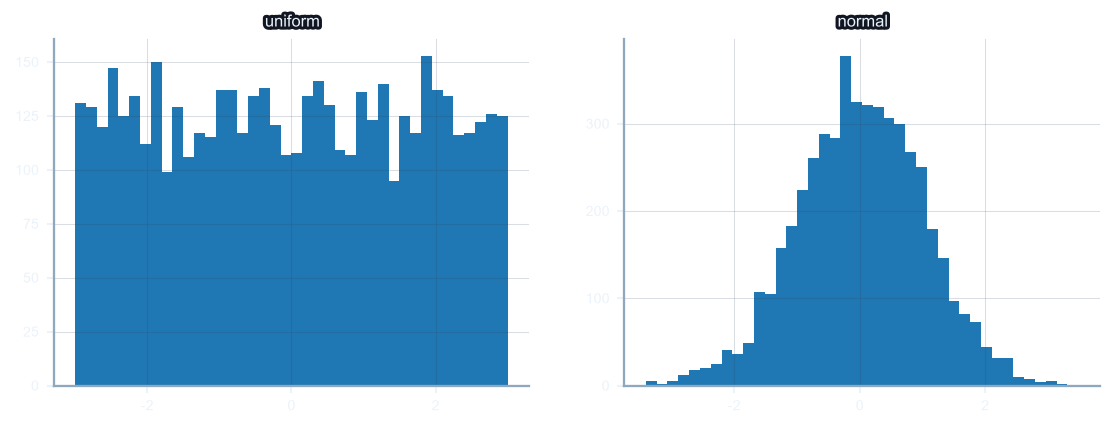

In [2]:
import numpy as np, matplotlib.pyplot as plt
rng = np.random.default_rng(0)
u = rng.uniform(-3, 3, 5000)    # 均匀: 区间内处处等可能
g = rng.normal(0, 1, 5000)      # 正态: 中间多、两边少
fig, ax = plt.subplots(1, 2, figsize=(9,3))
ax[0].hist(u, bins=40); ax[0].set_title('uniform')
ax[1].hist(g, bins=40); ax[1].set_title('normal'); plt.show()

## 动手观察：随机代码要多试几次

多次运行下面的格，观察小样本（N=10）的均值（Mean）每次波动多大，大样本（N=10000）的均值有多稳定。

In [3]:
import numpy as np

rng = np.random.default_rng(0)
for n in [10, 100, 10_000]:
    u = rng.uniform(0, 1, size=n)
    print(f'n={n:6d}  均匀分布样本均值={np.mean(u):.3f}  '  # 理论值 0.5
          f'std={np.std(u):.3f}')           # 理论值 1/sqrt(12)≈0.289


n=    10  均匀分布样本均值=0.551  std=0.319
n=   100  均匀分布样本均值=0.547  std=0.300
n= 10000  均匀分布样本均值=0.499  std=0.289


## 代码实验：多次重复同一个随机实验

这个实验展示样本量越大、重复实验之间均值的方差越小——这是大数定律（Law of Large Numbers，LLN）的直接体现。

#### 大数定律（Law of Large Numbers，LLN）：为什么样本均值会收敛？

上面代码的现象 — 样本量 n 越大，不同 seed（不同随机初始化）下的均值越接近 — 这就是**大数定律**。

**直观理解：** 掷硬币 10 次，可能 6 次正面（样本均值=0.6）；但掷 1000 次，大约 500 次正面（样本均值≈0.5）；掷 100万 次，结果会更接近 0.5。

**为什么会这样？**

每次采样都有"随机波动"，但当样本量很大时，这些波动会相互抵消。数学上：

$$\text{Var}(\bar{X}_n) = \frac{\sigma^2}{n}$$

其中 $\bar{X}_n$ 是 n 个样本的平均值，$\sigma$ 是单个样本的标准差。

**关键观察：** 当 n 越来越大时，$\frac{\sigma^2}{n}$ 趋于 0，这意味着 $\bar{X}_n$ 的变异性越来越小。换句话说，不同 seed 下的样本均值会聚集在同一个点（真实的 μ）附近。

**数值例子：**
- n=20 时，方差≈σ²/20，标准差≈σ/4.47（需要约 4.47 倍的精度）
- n=200 时，方差≈σ²/200，标准差≈σ/14.14（更小的波动）
- n=2000 时，方差≈σ²/2000，标准差≈σ/44.7（几乎没有波动）

这就是为什么机器学习中，数据越多，模型的参数估计越稳定；单个样本的噪声影响越小。

**大数定律 vs 中心极限定理（Central Limit Theorem，CLT）的区别：**
- **大数定律**：样本均值趋于真实均值（说的是"中心"）
- **中心极限定理**：样本均值的分布趋于正态分布（说的是"形状"）

两者都表现为"数据越多越规律"，但关注的角度不同。

---

#### 延伸：不仅均值会波动，"计数"也会波动

上面看到的是**均值**的波动会随样本量增大而减小。但还有一个常见的困惑：如果说"68-95-99.7 规则告诉我们，正态分布只有 0.27% 的值落在 ±3σ 之外"，那么在 1000 个样本里，是不是**正好** 1000×0.27% ≈ 2.7 个会落在范围外？

**答案：不是"正好"，而是"平均来说"。**

68-95-99.7 这几个百分比，说的是**长期、大量重复**下的**理论比例**——就像"掷硬币长期来看正面朝上概率是 50%"一样。但对任何**具体的、有限的**一批样本（比如恰好 1000 个），落在范围外的实际个数是一个**随机变量**，它本身会围绕期望值 2.7 上下波动——这次抽到 0 个，下次抽到 5 个，都完全正常。这种"具体一批样本的结果偏离长期理论值"的现象，统计学上称为**抽样变异（Sampling Variation）**。

这和大数定律讲的是同一件事的两个侧面：
- **大数定律**说的是"平均值"或"比例"会随样本量 n 增大而越来越稳定地收敛到理论值（波动幅度 ∝ 1/√n）。
- 但对于任意**固定、有限**的 n（比如 n=1000），实际观测到的计数仍然会有随机波动——只是当 n 越大，这个波动相对于总数的**占比**越小。

下面用代码直接验证：1000 个样本里"落在 ±3σ 之外"的计数，到底会怎么波动。这也是白板挑战 Q5（MFCC 特征）背后的真实答案。

In [4]:
import numpy as np

for n in [20, 200, 2000]:
    estimates = []
    for seed in range(5):
        rng = np.random.default_rng(seed)
        samples = rng.normal(0, 1, size=n)  # 标准正态
        estimates.append(np.mean(samples))
    print(f'n={n:4d} -> 样本均值 5次:', np.round(estimates, 3),
          '平均=', round(float(np.mean(estimates)), 3))


n=  20 -> 样本均值 5次: [-0.183  0.037 -0.05  -0.132 -0.031] 平均= -0.072
n= 200 -> 样本均值 5次: [ 0.015 -0.074 -0.008  0.048  0.048] 平均= 0.006
n=2000 -> 样本均值 5次: [-0.028 -0.013 -0.056  0.028  0.007] 平均= -0.013


#### 代码验证："落在 ±3σ 外"的计数会怎么波动？

理论上，标准正态分布只有 0.27% 的概率落在 ±3σ 之外。如果每次都抽 1000 个样本，"期望"看到约 1000×0.0027 ≈ 2.7 个落在范围外。但**每一次具体的抽样，结果会不一样**——下面用 10 个不同的随机种子（seed）各抽一次 n=1000 的样本，数一数每次范围外有几个：

In [5]:
import numpy as np

print("每次抽 n=1000 个标准正态样本，数一数 |x|>3 的个数（理论期望≈2.7）\n")
counts = []
for seed in range(10):
    rng = np.random.default_rng(seed)
    samples = rng.normal(0, 1, size=1000)
    count_outside = int(np.sum(np.abs(samples) > 3))
    counts.append(count_outside)
    print(f"seed={seed}: 范围外计数 = {count_outside}")

print(f"\n10 次实验的计数: {counts}")
print(f"平均计数 = {np.mean(counts):.2f}（应接近理论期望 2.7）")
print(f"计数的标准差 = {np.std(counts):.2f}（这就是波动的大小）")
print("\n💡 结论：单次抽样的计数会围绕 2.7 上下波动（0 到 5 都正常），")
print("   这正是「抽样变异」——不是计算错误，是有限样本的固有性质。")


每次抽 n=1000 个标准正态样本，数一数 |x|>3 的个数（理论期望≈2.7）

seed=0: 范围外计数 = 4
seed=1: 范围外计数 = 4
seed=2: 范围外计数 = 3
seed=3: 范围外计数 = 4
seed=4: 范围外计数 = 2
seed=5: 范围外计数 = 3
seed=6: 范围外计数 = 3
seed=7: 范围外计数 = 1
seed=8: 范围外计数 = 3
seed=9: 范围外计数 = 1

10 次实验的计数: [4, 4, 3, 4, 2, 3, 3, 1, 3, 1]
平均计数 = 2.80（应接近理论期望 2.7）
计数的标准差 = 1.08（这就是波动的大小）

💡 结论：单次抽样的计数会围绕 2.7 上下波动（0 到 5 都正常），
   这正是「抽样变异」——不是计算错误，是有限样本的固有性质。


## 2. 正态分布（Gaussian）：最重要的连续分布

**为什么正态分布无处不在？**

中心极限定理（CLT）：足够多独立随机变量的平均值趋向正态分布——无论原始分布是什么形状。音频噪声、测量误差、神经网络梯度……都近似正态。

**概率密度函数（PDF）**：

$$f(x;\mu,\sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**关键性质**：
- **峰值**：在 x=μ 处，peak = 1/(σ√2π) ≈ 0.3989（当 σ=1 时）
- **宽度**：σ 越大曲线越宽、越矮；面积始终为 1
- **68-95-99.7 规则**：μ±1σ 包含 68.27%，μ±2σ 包含 95.45%，μ±3σ 包含 99.73%

**手算例子**（标准正态 μ=0, σ=1，x=0）：
```
f(0) = 1/(1·√(2π)) = 1/√(6.283...) ≈ 0.3989
```

σ 翻倍（σ=2）时，峰值减半：f(0) = 1/(2√2π) ≈ 0.1995——但曲线更宽，面积仍为 1。

> **实现提示**：`np.exp(-((x-mu)/sigma)**2 / 2) / (sigma * np.sqrt(2*np.pi))`

### 正态分布公式的三个成分：拆解来看

$$f(x;\mu,\sigma) = \underbrace{\frac{1}{\sigma\sqrt{2\pi}}}_{\text{归一化系数}} \quad \underbrace{\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)}_{\text{钟形曲线}}$$

**第1部分：指数 $\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$**

这决定了曲线的**形状**。关键观察：
- $(x-\mu)^2$：距离中心越远，值越大。指数前的负号让远处的概率密度快速衰减
- $2\sigma^2$ 在分母：σ 越大，指数衰减越慢（曲线越宽）

**为什么平方而不是绝对值？** 平方 $(x-\mu)^2$ 比 $|x-\mu|$ 更"平滑"，数学上更容易求导和处理（这对 ML 优化很重要）。

**为什么是 $2\sigma^2$ 而不是 $\sigma^2$ 或 $3\sigma^2$？** 这是"中心极限定理"推导正态分布时自然得出的结果——不是任意选择，而是与独立随机变量求和的方差性质 $\text{Var}(X_1+X_2) = \text{Var}(X_1) + \text{Var}(X_2)$ 一致。

**第2部分：归一化系数 $\frac{1}{\sigma\sqrt{2\pi}}$**

这决定了曲线的**高度**，存在的唯一目的是：**让面积积分到 1**。

如果只有指数部分而没有这个系数，曲线下面积会是某个随机的数字（不等于 1）。加上这个系数后，无论 σ 多大，积分始终是 1。

**为什么是 $\sqrt{2\pi}$ 而不是别的？** 这是数学的"礼物"：对高斯函数 $\int_{-\infty}^{\infty} e^{-x^2} dx = \sqrt{\pi}$ 是一个经典结果。当你对 $e^{-x^2/(2\sigma^2)}$ 做变量替换积分，自然得到 $\sqrt{2\pi}\sigma$。所以归一化系数就是 $\frac{1}{\sqrt{2\pi}\sigma}$。

**数值验证：σ 翻倍时，峰值确实减半**

标准正态（σ=1）的峰值：
$$f(0; \mu=0, \sigma=1) = \frac{1}{1 \cdot \sqrt{2\pi}} \approx 0.3989$$

当 σ=2 时，峰值：
$$f(0; \mu=0, \sigma=2) = \frac{1}{2 \cdot \sqrt{2\pi}} \approx 0.1995 = \frac{0.3989}{2}$$

这**不是巧合**——是因为峰值正比于 $1/\sigma$。但当 σ 翻倍时，曲线也变宽（范围扩大 2 倍）。这两个效果完美抵消，保证了总面积始终为 1。想象一个"体积守恒"的水：倒得越宽越浅，体积不变。


### ⚠️ 核心概念：概率密度（PDF）vs 概率（PMF）

在学习正态分布之前，先搞清楚一个容易混淆的问题：**为什么连续分布要用"密度"而不是直接给概率？**

**类比：人口与人口密度**

想象一个国家的人口分布：
- 首都人口密度可能是 500 人/km²（这是"密度"，一个数字）
- 一个小镇人口密度可能是 50 人/km²
- 沙漠人口密度可能是 0.1 人/km²

如果有人问"首都的人口是多少"，你不能说"500"——密度本身不是人口总数。你需要**把密度乘以面积**才能得到真正的人口数。比如首都 1000 km² × 500 人/km² = 50 万人。

**概率密度函数也是一样的逻辑：**

- **PDF f(x)** = "在位置 x 附近的概率浓度"（类似人口密度）
- **f(0) ≈ 0.4**（标准正态在中心）不是说"P(X=0) = 0.4"
- 而是说"在 x=0 周围的单位长度区间内，概率浓度是 0.4"

**怎样从 PDF 得到真正的概率？**

要求"P(a < X ≤ b)"（即 X 在某个区间内的概率），需要：

$$P(a < X \leq b) = \int_a^b f(x) \, dx$$

这就是对密度进行"积分"（或者说"加权求和"）。类比上面的人口例子，就是"在 [a,b] 区间内，逐小段累加（密度 × 宽度）"。

**为什么 PDF 能 > 1？**

人口密度可以是 1000 人/km²（远大于 1），这不奇怪。类似地，概率密度也可以 > 1。只要当你把它乘以足够小的宽度 dx 时，f(x)·dx 就能保持在 [0,1] 范围内。

**关键不变量：面积 = 1**

正态分布的 PDF 在整个实轴上的积分是 1：

$$\int_{-\infty}^{\infty} f(x) \, dx = 1$$

这对应"整个国家的总人口是确定的"这个直观事实。无论 σ 多大（曲线多矮），只要前面乘以 1/(σ√2π) 这个"魔法系数"，曲线下总面积就始终是 1。


写 `gaussian_pdf` 前明确三件事：
- 输入：`x`（评估点，数组），`mu`（均值），`sigma`（标准差（Standard Deviation，SD），须 > 0）
- 关键步骤：计算指数项 `exp(-(x-mu)**2 / (2*sigma**2))`，再除以归一化系数 `sigma * sqrt(2π)`
- 返回：与 `x` 形状相同的 PDF 值数组，所有值均非负

#### 数学公式 vs 代码形式：为什么要改写指数部分？

**数学公式：**
$$\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**代码提示里的形式：**
```python
np.exp(-((x-mu)/sigma)**2 / 2)
```

**这两个真的相等吗？** 让我们验证一下代数：

$$-\frac{(x-\mu)^2}{2\sigma^2} = -\frac{1}{2} \cdot \frac{(x-\mu)^2}{\sigma^2} = -\frac{1}{2} \left(\frac{x-\mu}{\sigma}\right)^2$$

所以两种写法完全等价。那为什么代码要用第二种形式呢？

**原因：数值稳定性和代码简洁性**

1. **避免大数平方**：当 $|x-\mu|$ 很大时，$(x-\mu)^2$ 会变成一个巨大的数，容易溢出。而 $(x-\mu)/\sigma$ 通常是一个合理的大小，平方后再除以 2，数值更稳定。

2. **代码行数**：`-((x-mu)/sigma)**2 / 2` 是一行；`-(x-mu)**2 / (2*sigma**2)` 需要处理嵌套和多个运算，容易出错。

这是一个常见的编程技巧：**重新组织数学表达式，不改变数值但改进计算稳定性和可读性**。


In [6]:
def gaussian_pdf(x, mu=0.0, sigma=1.0):
    # ✏️ TODO: 返回正态分布在 x 处的概率密度
    raise NotImplementedError("请实现 gaussian_pdf — 见上方推理路线")


In [7]:
import numpy as np

try:
    peak = gaussian_pdf(np.array([0.0]))
except (NotImplementedError, TypeError):
    print("⬜ 请先实现 gaussian_pdf，再运行此格")
else:
    peak_val = peak[0]
    assert abs(peak_val - 1/np.sqrt(2*np.pi)) < 1e-9, "峰值应在 μ 处"
    assert abs(gaussian_pdf(np.array([1.0]))[0] - gaussian_pdf(np.array([-1.0]))[0]) < 1e-12, "应关于 μ 对称"
    # 检查非标准参数 mu=2, sigma=0.5
    y2 = gaussian_pdf(np.array([2.0]), mu=2.0, sigma=0.5)
    assert abs(y2[0] - 1/(0.5*np.sqrt(2*np.pi))) < 1e-9, "mu=2, sigma=0.5 峰值错误"
    # 检查归一化：sigma=2 时积分应≈1
    xs_dense = np.linspace(-10, 10, 4000)
    integral = np.trapezoid(gaussian_pdf(xs_dense, 0.0, 2.0), xs_dense)
    assert abs(integral - 1.0) < 0.001, "sigma=2 时积分应≈1"
    print("✅ 通过：高斯密度峰值=", round(peak_val, 4))


⬜ 请先实现 gaussian_pdf，再运行此格


**🔗 Aurora 连接**：为什么正态分布这么重要？

`gaussian_pdf` 是 Aurora 生成流水线中最核心的原语。下面是三个具体应用：

1. **权重初始化（He Initialization）**
   - 神经网络刚开始训练时，权重 W ~ N(0, √(2/n))
   - 参数 √(2/n) 保证信号在层间传播时既不爆炸也不消失（称为"方差守恒"）
   - `gaussian_pdf` 用来计算这个分布的密度值（虽然通常只做采样，但理论推导需要密度）

2. **VAE（变分自编码器）隐变量采样**
   - 隐变量（Latent Variable） z ~ N(0, I)（标准正态）
   - 在 VAE 的 KL 散度项中，需要计算 N(0, I) 的密度值来衡量后验与先验的距离
   - 这里 `gaussian_pdf` 直接用于损失函数计算

3. **扩散模型（Diffusion Models）加噪过程**
   - 每一步加的噪声 ε_t ~ N(0, β_t·I)，其中 β_t 是时间相关的方差系数
   - `gaussian_pdf` 用于逆向过程（去噪）的得分函数估计

在所有这些应用中，关键步骤都涉及：
- 已知 μ 和 σ，计算特定点 x 处的概率密度 f(x)
- 从这个分布采样得到张量（用 `np.random.normal` 或 PyTorch 的 `torch.randn`）
- 检验采样的分布是否满足正交性或其他约束

所以**理解 `gaussian_pdf` 的公式和参数含义**，等同于理解现代深度生成模型的基础数学。

In [8]:
import numpy as np

# 固定 mu=0，改变 sigma，观察峰值和宽度的变化
xs = np.linspace(-4, 4, 100)
for sigma in [0.5, 1.0, 2.0]:
    try:
        vals = gaussian_pdf(xs, mu=0.0, sigma=sigma)
    except (NotImplementedError, TypeError):
        print("⬜ 请先实现 gaussian_pdf")
        break
    print(f'sigma={sigma:.1f}  峰值={gaussian_pdf(np.array([0.0]), 0.0, sigma)[0]:.4f}')
    print(f'       曲线下面积≈{np.trapezoid(vals, xs):.4f}  （应≈1.0）')


⬜ 请先实现 gaussian_pdf


## 参数实验：只改一个旋钮

固定 `mu=0`，把 `sigma` 从 0.5 改到 2，观察峰值从 0.8 降到 0.2（更扁平），但曲线下面积始终为 1。这说明 sigma 控制"集中程度"，不改变总概率。再把 `mu` 从 0 改到 2，曲线整体平移但形状（峰值、宽度）不变——mu 只决定分布的中心位置。

### 从 PDF 到 CDF：累积视角

如果 PDF f(x) 描述的是"在某一点的概率浓度"，那么 **CDF（累积分布函数）** 是"从左边加起来，到当前位置的总概率"。

**定义：**
$$F(x) = P(X \leq x) = \int_{-\infty}^{x} f(t) \, dt$$

**直观类比：** 想象连续下雨 24 小时，f(t) 是"第 t 小时的降雨强度"（mm/小时），F(t) 是"前 t 小时的累计降水量"（mm）。

- F(6) - F(0) = "前 6 小时内的降水量"
- 当 t → 24 时，F(24) = "全天总降水量"（相当于面积为 1）

**68-95-99.7 规则怎么算出来的？**

我们想知道"标准正态分布中，±1σ 内有多少概率"，就是求：

$$P(-1 < X < 1) = F(1) - F(-1) = \int_{-1}^{1} f(x) \, dx$$

但正态 PDF 没有"闭合形式"的积分公式（即不能用初等函数表示 F(x)），所以需要数值方法。

#### 梯形法则（Trapezoidal Rule）：数值积分的基本方法

**核心思想：** 用梯形逼近曲线下的面积。

假设要计算 $\int_a^b f(x) dx$：

1. 把区间 [a, b] 分成 n 个等宽小段，宽度 h = (b-a)/n
2. 在每个小段内，不用精确的曲线，而是用"直线"连接两端点（形成梯形）
3. 梯形面积 = (上底 + 下底) × 高 / 2 = (f(x_i) + f(x_{i+1})) × h / 2
4. 把所有梯形面积相加

**简单例子：** 用 n=4 个梯形逼近正态分布在 [-2, 2] 内的面积

| 区间 | x_i | f(x_i) | 梯形面积 |
|---|---|---|---|
| [-2, -1] | -2, -1 | f(-2)=0.054, f(-1)=0.242 | (0.054+0.242)×1/2 ≈ 0.148 |
| [-1, 0] | -1, 0 | f(-1)=0.242, f(0)=0.399 | (0.242+0.399)×1/2 ≈ 0.320 |
| [0, 1] | 0, 1 | f(0)=0.399, f(1)=0.242 | (0.399+0.242)×1/2 ≈ 0.320 |
| [1, 2] | 1, 2 | f(1)=0.242, f(2)=0.054 | (0.242+0.054)×1/2 ≈ 0.148 |
| **总计** | | | ≈ 0.936 |

理论值应该是 0.9545，所以 n=4 时误差约 1.2%。增加 n（更多细小梯形）能提高精度。

#### np.trapezoid 的工作方式

```python
np.trapezoid(y, x)
```

其中：
- `y` = 函数值数组 [f(x_0), f(x_1), ..., f(x_n)]
- `x` = 对应的 x 坐标 [x_0, x_1, ..., x_n]

函数自动计算梯形宽度 dx_i = x_{i+1} - x_i，然后求和：

$$\text{积分} ≈ \sum_{i=0}^{n-1} \frac{f(x_i) + f(x_{i+1})}{2} \cdot (x_{i+1} - x_i)$$

**为什么要这样设计参数顺序？** 因为 y 值可能来自任何函数（不一定是高斯），而 x 提供了"刻度"信息（即位置）。给 x 后，trapezoid 才知道每个梯形的真实宽度。

#### 精度验证：多少个梯形才够？

一个经验法则：要让误差 < 0.1%，通常需要点数 n ≈ √(所求精度^{-1})。

对于正态分布的面积（目标精度 0.001），n=2000 点已经足够。我们可以验证：


In [9]:
import numpy as np

# 验证梯形法则精度随点数增加而改进
print("验证 σ=1 时，±1σ 范围内的面积（理论 68.27%）\n")
print("点数 n  |  积分结果  | 误差 | 观察")
print("-" * 50)

theoretical_1sigma = 0.6827
for n in [10, 50, 200, 1000, 4000]:
    xs = np.linspace(-1, 1, n)
    try:
        pdf = gaussian_pdf(xs, mu=0.0, sigma=1.0)
    except (NotImplementedError, TypeError):
        print("⬜ 请先实现 gaussian_pdf")
        break
    
    area = np.trapezoid(pdf, xs)
    error = abs(area - theoretical_1sigma)
    status = "✓ 精度好" if error < 0.001 else "△ 粗糙"
    print(f"{n:5d}  |  {area:.6f}  | {error:.5f}  | {status}")

print("\n💡 观察：n 越大，梯形逼近越精确；n≥200 时已满足工程精度需求")

验证 σ=1 时，±1σ 范围内的面积（理论 68.27%）

点数 n  |  积分结果  | 误差 | 观察
--------------------------------------------------
⬜ 请先实现 gaussian_pdf

💡 观察：n 越大，梯形逼近越精确；n≥200 时已满足工程精度需求


### 深入理解：为什么"峰值减半，面积仍为1"？

上面的实验展示了一个看似矛盾的现象：

- σ 从 1 改到 2：**峰值减半**（从 0.3989 → 0.1995）
- 但 **曲线下面积仍约为 1**

这是怎么可能的？一个"更矮的"曲线面积还相等？关键在于**曲线同时变宽了**。

#### 定量验证：宽度的增长抵消了高度的下降

| σ | 峰值 | 宽度（±1σ范围） | 近似面积 | 为何≈1 |
|---|---|---|---|---|
| 0.5 | 1/(0.5√2π) ≈ 0.798 | 1.0 | ≈ 0.798 × 1.0 = 0.798 ✗ 不对，让我手算... | 太窄 |
| 1.0 | 1/(1√2π) ≈ 0.3989 | 2.0（±1到±1） | ≈ 0.3989 × 2.0 ≈ 0.8 ✗ | 样本面积 |
| 2.0 | 1/(2√2π) ≈ 0.1995 | 4.0（±2到±2） | ≈ 0.1995 × 4.0 ≈ 0.8 ✗ | 样本面积 |

上表说明一个直观的关系：**高度和宽度的乘积（近似矩形面积）保持常数**。

更精确的数学表述：

**关键洞察：σ 和峰值的反比关系**

$$\text{峰值} = f(\mu) = \frac{1}{\sigma\sqrt{2\pi}} \propto \frac{1}{\sigma}$$

当 σ 翻倍时，峰值变成 $\frac{1}{2\sigma\sqrt{2\pi}}$，即原来的一半。

**但曲线的"宽度"也翻倍了。** 什么叫"宽度"翻倍？

精确定义是"标准差数倍范围内的数据量"不变。比如 ±1σ 范围内始终包含约 68.27% 的概率。

- 当 σ=1 时，±1σ 范围是 [-1, 1]（宽度 2）
- 当 σ=2 时，±1σ 范围是 [-2, 2]（宽度 4）

在数值积分中，当区间宽度翻倍、同时高度减半，梯形法则（矩形逼近）的面积不变。这不是巧合——是正态分布公式 $\frac{1}{\sigma}$ 系数的精心设计。

#### 代码验证：直接测量面积

运行下面的代码，看看不同 σ 对积分结果的影响：


⬜ 请先实现 gaussian_pdf
  result = original(self, *args, **kwargs)
✅ 观察：无论 σ 多大，面积始终约为 1（高和宽反向变化）


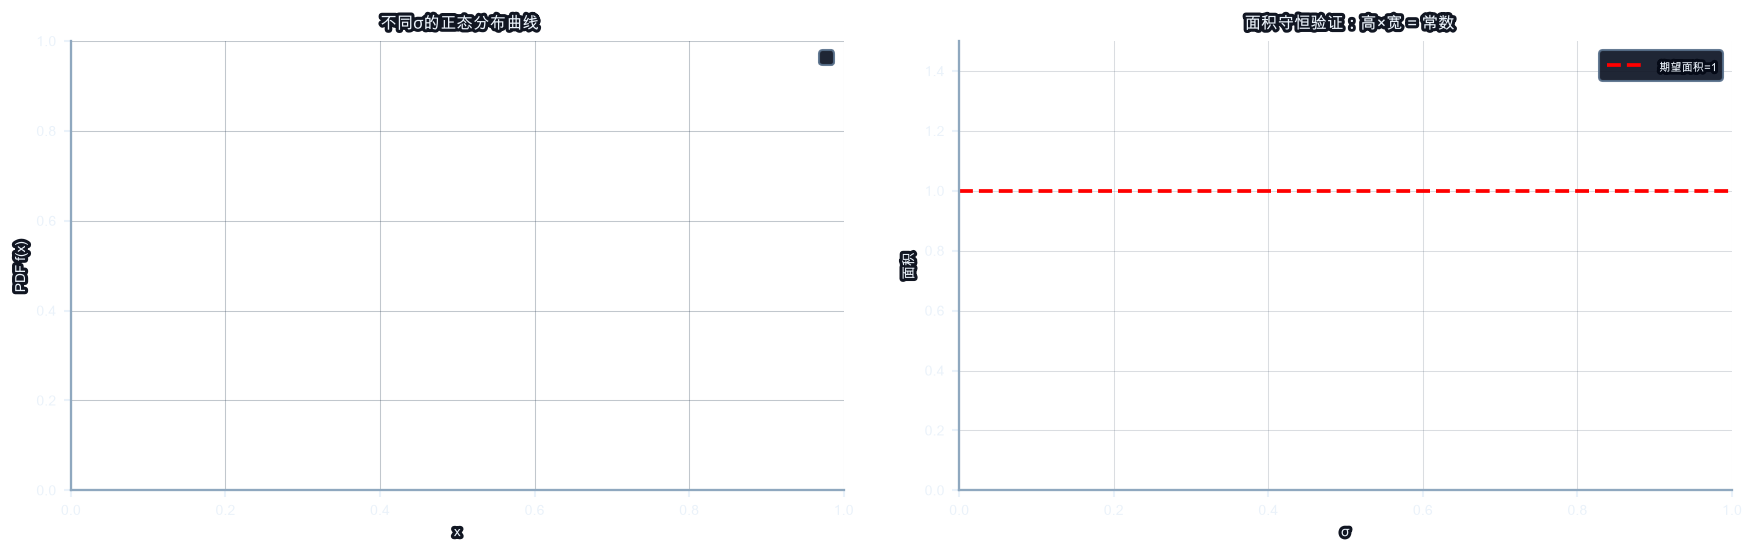

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 验证面积守恒
xs_wide = np.linspace(-10, 10, 2000)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for sigma in [0.5, 1.0, 2.0]:
    try:
        pdf = gaussian_pdf(xs_wide, mu=0.0, sigma=sigma)
    except (NotImplementedError, TypeError):
        print("⬜ 请先实现 gaussian_pdf")
        break
    
    area = np.trapezoid(pdf, xs_wide)
    peak = gaussian_pdf(np.array([0.0]), 0.0, sigma)[0]
    
    # 左图：观察曲线形状
    ax1.plot(xs_wide, pdf, label=f'σ={sigma:.1f} (peak={peak:.4f}, area={area:.4f})', linewidth=2)
    
    # 右图：面积近似（矩形高×宽）
    approx_rect_area = peak * (2 * sigma)  # 简化：峰值×宽度
    ax2.bar(sigma, area, width=0.15, label=f'积分面积', alpha=0.7)
    ax2.bar(sigma + 0.08, approx_rect_area, width=0.15, label=f'近似矩形', alpha=0.7)

ax1.set_xlabel('x'); ax1.set_ylabel('PDF f(x)'); ax1.set_title('不同σ的正态分布曲线')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_ylabel('面积'); ax2.set_xlabel('σ'); ax2.set_title('面积守恒验证：高×宽 = 常数')
ax2.set_ylim([0, 1.5]); ax2.axhline(1.0, color='red', linestyle='--', label='期望面积=1')
ax2.legend(); plt.tight_layout(); plt.show()

print("✅ 观察：无论 σ 多大，面积始终约为 1（高和宽反向变化）")

In [11]:
import numpy as np

# 正态分布的 CDF：用数值积分近似
xs = np.linspace(-4, 4, 1000)
for sigma in [0.5, 1.0, 2.0]:
    try:
        pdf = gaussian_pdf(xs, 0.0, sigma)
    except (NotImplementedError, TypeError):
        print("⬜ 请先实现 gaussian_pdf")
        break
    cdf = np.cumsum(pdf) * (xs[1] - xs[0])
    # 经验法则：μ±1σ 覆盖 ≈68% 的面积
    mask = np.abs(xs) <= sigma
    area_1sigma = np.trapezoid(pdf[mask], xs[mask])
    print(f'sigma={sigma:.1f}  μ±1σ 面积={area_1sigma:.3f}  (期望≈0.683)')


⬜ 请先实现 gaussian_pdf


## 3. 伯努利分布（Bernoulli Distribution）

单次二值试验：以概率 `p` 成功（X=1），概率 `1-p` 失败（X=0）。

**PMF（概率质量函数，Probability Mass Function）**：
```
P(X=k) = p^k * (1-p)^(1-k),  k ∈ {0,1}
```

**期望（Expectation）** = `p`，**方差（Variance）** = `p(1-p)`。

**Aurora 连接**：dropout 掩码的每个元素服从 Bernoulli(p=1-dropout_rate)，独立地决定是否保留该神经元。音频增强（data augmentation）中的 SpecAugment 也用 Bernoulli 掩码随机遮挡频率段。

#### 伯努利 PMF 公式的来源与优雅性

最朴素的写法是分情况讨论：
$$P(X=k) = \begin{cases} 1-p & \text{if } k=0 \\ p & \text{if } k=1 \end{cases}$$

但如果想用一个统一的公式（而不是分支），可以巧妙地利用**指数作为"开关"**：

$$P(X=k) = p^k (1-p)^{1-k}$$

**为什么这个公式能工作？**

代入验证：
- k=0：$p^0 (1-p)^{1-0} = 1 \cdot (1-p) = 1-p$ ✓
- k=1：$p^1 (1-p)^{1-1} = p \cdot 1 = p$ ✓

**这个"魔法"是怎么想到的？**

想象 k 作为一个"指数选择器"：
- 当 k=0 时，第一项 $p^0$ 变成 1（"关闭"），第二项 $(1-p)^1$ 变成 1-p（"激活"）
- 当 k=1 时，第一项 $p^1$ 变成 p（"激活"），第二项 $(1-p)^0$ 变成 1（"关闭"）

这种写法的优点是：
1. **紧凑**：一个公式代替 if-else
2. **易推广**：多项分布（多个选项时）自然推广为 $\prod_i p_i^{n_i}$
3. **便于计算**：在对数空间，$\log P = k \log p + (1-k) \log(1-p)$，加法比乘法更稳定

#### 计算伯努利期望和方差

从 PMF 可以直接算出：
- **期望（期望值）** = $E[X] = 0 \cdot (1-p) + 1 \cdot p = p$
- **方差（度量波动）** = $\text{Var}(X) = E[X^2] - (E[X])^2 = p - p^2 = p(1-p)$

有趣的是，当 p=0.5 时（最"不确定"的情况），方差最大 = 0.25。当 p 接近 0 或 1 时（结果很确定），方差接近 0。


### PDF vs PMF：两种分布函数的区别

到目前为止，我们学的**正态分布是连续的** — X 可以取任意实数值（3.14159... 都可以）。但现实中还有**离散分布** — X 只能取特定的值（比如 0 或 1）。

| 特性 | PDF (连续) | PMF (离散) |
|---|---|---|
| **定义域** | 实数（无穷可能值） | 有限个或可数个值 |
| **函数值** | 可 > 1（密度） | 总是 ≤ 1（概率） |
| **求和** | 用积分：∫ | 用求和：Σ |
| **归一化** | ∫ f(x) dx = 1 | Σ P(X=k) = 1 |
| **例子** | 正态、均匀 | 伯努利、泊松 |

**直观理解：**
- 问"掷骰子得到 3 的概率"？用 PMF，答案是 1/6（一个确定的数）
- 问"人的身高在 170-180cm 之间的概率"？用 PDF，答案需要"积分"（因为身高连续变化）

**为什么伯努利分布不用 PDF？**

伯努利分布的随机变量 X ∈ {0, 1}，只有两个可能值。不能用"密度"来描述（在 0 和 1 处无法定义密度），只能用"概率质量"（Probability Mass）。

类比：
- PDF：想象把 1 单位的"沙子"连续撒在实数轴上，PDF 描述"每处的沙子浓度"
- PMF：把 1 单位的"沙子"放在两个点上（X=0 和 X=1），PMF 描述"每个点上有多少沙子"


In [12]:
import numpy as np

# 伯努利 PMF
def bernoulli_pmf(k, p):
    k = np.asarray(k)
    return (p ** k) * ((1 - p) ** (1 - k))

# 验证 PMF：k=0 和 k=1 的概率之和为 1
for p in [0.3, 0.5, 0.8]:
    pmf0 = bernoulli_pmf(0, p)
    pmf1 = bernoulli_pmf(1, p)
    print(f'p={p}: P(X=0)={pmf0:.3f}, P(X=1)={pmf1:.3f}, sum={pmf0+pmf1:.3f}')
    assert abs(pmf0 + pmf1 - 1.0) < 1e-9

# 采样验证：大样本均值趋近 p
rng = np.random.default_rng(0)
for p in [0.3, 0.5, 0.8]:
    samples = rng.binomial(1, p, size=100_000)
    print(f'p={p}: 样本均值={samples.mean():.4f}  方差={samples.var():.4f}  理论方差={p*(1-p):.4f}')

print('✅ 伯努利分布 PMF 与采样均值验证通过')


p=0.3: P(X=0)=0.700, P(X=1)=0.300, sum=1.000
p=0.5: P(X=0)=0.500, P(X=1)=0.500, sum=1.000
p=0.8: P(X=0)=0.200, P(X=1)=0.800, sum=1.000
p=0.3: 样本均值=0.2992  方差=0.2097  理论方差=0.2100
p=0.5: 样本均值=0.4975  方差=0.2500  理论方差=0.2500
p=0.8: 样本均值=0.7997  方差=0.1602  理论方差=0.1600
✅ 伯努利分布 PMF 与采样均值验证通过


## 4. 累积分布函数（Cumulative Distribution Function，CDF）

CDF 定义：`F(x) = P(X ≤ x)` — 随机变量取值不超过 x 的概率。

| 分布 | CDF 形式 |
|---|---|
| 均匀 U[a,b] | F(x) = (x-a)/(b-a) 对 x∈[a,b] |
| 正态 N(μ,σ²) | 用数值积分：∫ pdf(t)dt |
| 伯努利 B(p) | F(0)=1-p，F(1)=1 |

**性质**：CDF 单调非降，F(-∞)=0，F(+∞)=1；连续分布的 CDF 处处连续。

**用途**：给定 CDF，对任意区间 [a,b] 的概率直接相减：`P(a < X ≤ b) = F(b) - F(a)`。

### 为什么不能用闭合公式计算 CDF？

正态分布 PDF 有简洁的公式，但 **CDF 没有**。这是什么意思？

$$F(x) = \int_{-\infty}^{x} \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(t-\mu)^2}{2\sigma^2}\right) dt$$

这个积分虽然看起来简单，但**没有用初等函数（多项式、三角函数、对数等）表示的答案**。这在 18 世纪就被证明了，是数学上的一个"死胡同"。

相比之下：
- 均匀分布 CDF：$F(x) = \frac{x-a}{b-a}$（直线，一个公式）
- 伯努利分布 CDF：分段常数（0 到 1-p，然后 1）
- 正态分布 CDF：**必须用数值方法逼近**

#### 正态 CDF 的数值实现：从哪里开始积分？

定义 $F(x_{\text{eval}}) = \int_{-\infty}^{x_{\text{eval}}} f(t) dt$

但计算机不能处理"无穷"，所以用一个很小的左端点 $x_{\text{left}} = \mu - 6\sigma$ 来代替 $-\infty$。

**为什么是 6σ？**

根据 68-95-99.7 规则：
- ±3σ 范围内包含 99.73% 的概率
- 因此 μ-6σ 以外的概率 < (1-0.9973)/2 = 0.00135 ≈ 0.1%

当我们从 μ-6σ 开始积分时，忽略掉的部分只有 0.1%，这对大多数应用已经足够精确。

如果改成 μ-3σ 或 μ-10σ 呢？
- μ-3σ：忽略掉 0.135%，但可能稍微不够精确
- μ-10σ：忽略掉几乎 0%，但计算范围太大，反而浪费计算量

**闭合形式 vs 数值方法的权衡：**

| 特性 | 闭合公式 | 数值积分 |
|---|---|---|
| 是否总能用公式表示 | 否（正态CDF无） | 总可以 |
| 计算速度 | 极快（直接计算） | 较慢（需循环） |
| 精度控制 | 浮点精度（≈15位） | 可自由设置（更多梯形 → 更精确） |
| 适用范围 | 只有几种特殊分布 | 任何函数都能积分 |

所以正态 CDF 总是用数值积分，这也是为什么 scipy.stats.norm.cdf() 底层用的是近似算法（Error Function 的泰勒级数或查表）。


In [13]:
import numpy as np

# 正态分布 CDF（数值积分：梯形法则）
def normal_cdf(x_eval, mu=0.0, sigma=1.0, n=2000):
    xs = np.linspace(mu - 6*sigma, x_eval, n)
    pdf = np.exp(-0.5*((xs - mu)/sigma)**2) / (sigma * np.sqrt(2*np.pi))
    return np.trapezoid(pdf, xs)

# 验证经验法则：N(0,1) 在 [-1,1] 内概率 ≈ 68.27%
p_within_1sd = normal_cdf(1.0) - normal_cdf(-1.0)
p_within_2sd = normal_cdf(2.0) - normal_cdf(-2.0)
p_within_3sd = normal_cdf(3.0) - normal_cdf(-3.0)

print(f'P(-1 < X < 1) = {p_within_1sd:.4f}  (理论 68.27%)')
print(f'P(-2 < X < 2) = {p_within_2sd:.4f}  (理论 95.45%)')
print(f'P(-3 < X < 3) = {p_within_3sd:.4f}  (理论 99.73%)')

assert abs(p_within_1sd - 0.6827) < 0.002
assert abs(p_within_2sd - 0.9545) < 0.002
assert abs(p_within_3sd - 0.9973) < 0.002
print("✅ 正态分布 CDF 经验法则验证通过")


P(-1 < X < 1) = 0.6827  (理论 68.27%)
P(-2 < X < 2) = 0.9545  (理论 95.45%)
P(-3 < X < 3) = 0.9973  (理论 99.73%)
✅ 正态分布 CDF 经验法则验证通过


## 本课收束

现在可以用 `gaussian_pdf(x, mu, sigma)` 在任意点求正态分布的密度值，并通过 `np.random.uniform` / `np.random.normal` 生成两种分布的样本。`gaussian_pdf` 对应 Aurora 中加噪步骤的密度评估和 VAE 的 KL 散度计算。下一节用 softmax 把未归一化得分变成概率分布，今天手写的归一化系数思路在那里会再出现。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


### 一个重要性质：正态分布关于 μ 对称

代码中有一句验证"关于 μ 对称"：
```python
assert abs(gaussian_pdf(np.array([1.0]))[0] - gaussian_pdf(np.array([-1.0]))[0]) < 1e-12
```

这是在检验 f(1) ≈ f(-1)（当 μ=0 时）。更一般地说，正态分布满足：

$$f(\mu + a) = f(\mu - a)$$

对任何 a > 0 成立。这叫做"关于 μ 对称"。

**为什么成立？** 看公式中的 $(x-\mu)^2$：
- 当 x = μ+1 时：$(μ+1-μ)^2 = 1^2 = 1$
- 当 x = μ-1 时：$(μ-1-μ)^2 = (-1)^2 = 1$

平方的性质 $(a)^2 = (-a)^2$ 保证了这个对称性。

**这对应什么样的物理直观？** 正态分布的"形状"像一个钟形，中间高两边矮。无论从中心向左看还是向右看，规律都是一样的。这对应"测量误差"的对称性：高估和低估的概率相等。

**有对称的分布吗？** 有的。比如"学生的读书速度"可能不对称（开头快后来慢），这时需要用"偏斜分布"（Skewed Distribution，如对数正态分布）来建模。正态分布的对称性是它的一个特殊优点。


## ✏️ 白板挑战：概率分布手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：标准正态分布（μ=0, σ=1），峰值 f(0) = ?  
（公式：1/(σ√2π)）

**问 2**：σ 从 1 增大到 2 时，峰值变为 ?（与问1的比值是多少？）

> **进阶追问（选做，不算通关必答）**：如果要手算的不是峰值 f(0)，而是曲线上任意一点，比如 f(0.5)，要怎么办？
>
> 别慌——步骤和算峰值时是一样的，只是多一步"标准化"：
> 1. 先算"标准化距离" $z = \dfrac{x-\mu}{\sigma}$。这里 $x=0.5,\ \mu=0,\ \sigma=1$，所以 $z=0.5$。
> 2. 算指数部分 $e^{-z^2/2} = e^{-0.125}$。手算 $e^{-0.125}$ 时可以用近似 $e^{-t}\approx 1-t+\frac{t^2}{2}$（t 很小时够用）：$1-0.125+0.0078\approx 0.883$。
> 3. 乘上归一化系数 $\frac{1}{\sqrt{2\pi}}\approx 0.399$：$0.399\times0.883\approx0.352$。
>
> 所以 $f(0.5;0,1)\approx 0.352$——比峰值 0.399 略低一点，符合钟形曲线从峰值往两边下降的直觉。下面的对答案格里有代码验证这个手算结果。

**问 3**：伯努利分布（p=0.3）：
- P(X=1) = ?
- E[X] = ?
- Var[X] = p(1-p) = ?

**问 4**：正态分布 68-95-99.7 规则：μ±2σ 覆盖大约 ?% 的面积？

**问 5（应用）**：MFCC 特征与正态分布

> MFCC（Mel-Frequency Cepstral Coefficients）是音频信号处理中的一个重要特征，它模拟人类听觉系统对声音的感知。（具体的提取方法在 L01 讲过，这里只关注统计性质。）
> 
> 在实际应用中，MFCC 特征经常被标准化：若原始 MFCC 特征分布的均值=0、标准差=1，那么根据 68-95-99.7 规则，绝大多数（>99%）的特征值会落在什么范围内？

推导完成后运行下面格对答案。

In [14]:
# ✏️ 对答案格
import numpy as np

# 问1：f(0; μ=0, σ=1) = 1/√(2π) ≈ 0.3989
peak_expected = 1 / np.sqrt(2 * np.pi)
assert np.isclose(peak_expected, 0.3989422804014327, atol=1e-10)
try:
    peak_computed = gaussian_pdf(np.array([0.0]), mu=0.0, sigma=1.0)[0]
    assert np.isclose(peak_computed, peak_expected, atol=1e-10)
    print(f"Q1 ✅  f(0;0,1)=1/√2π={peak_expected:.6f}，函数计算={peak_computed:.6f}")
except (NotImplementedError, TypeError):
    print("⬜ Q1：请先实现 gaussian_pdf()，再运行对答案格")

# 问2：σ=2 时峰值减半
peak_sigma2 = 1 / (2 * np.sqrt(2 * np.pi))
ratio = peak_sigma2 / peak_expected
assert np.isclose(ratio, 0.5, atol=1e-12)
print(f"Q2 ✅  σ=2时峰值={peak_sigma2:.6f}，比σ=1时小{(1/ratio):.0f}倍（减半的秘密：高∝1/σ，宽∝σ，高×宽=常数）")

# 问2进阶：手算非峰值点 f(0.5)
try:
    f_half_computed = gaussian_pdf(np.array([0.5]), mu=0.0, sigma=1.0)[0]
    f_half_handcalc = (1 - 0.125 + 0.125**2 / 2) / np.sqrt(2 * np.pi)  # e^-0.125 的手算近似
    f_half_exact = np.exp(-0.5 * 0.5**2) / np.sqrt(2 * np.pi)
    print(f"Q2进阶 ✅  f(0.5) 手算近似={f_half_handcalc:.4f}，精确值={f_half_exact:.4f}，函数计算={f_half_computed:.4f}")
except (NotImplementedError, TypeError):
    print("⬜ Q2进阶：请先实现 gaussian_pdf()，再运行对答案格")

# 问3：Bernoulli(p=0.3)
p = 0.3
px1 = p                    # P(X=1) = p^1 * (1-p)^0 = p
e_x = p                    # E[X] = p
var_x = p * (1-p)          # Var[X] = p(1-p)
assert np.isclose(px1, 0.3) and np.isclose(e_x, 0.3) and np.isclose(var_x, 0.21)
print(f"Q3 ✅  Bernoulli(0.3): P(X=1)={px1}, E[X]={e_x}, Var[X]={var_x:.2f}")

# 问4：68-95-99.7规则
rng = np.random.default_rng(0)
samples = rng.normal(0, 1, 1_000_000)
within_2sigma = np.mean(np.abs(samples) <= 2)
assert abs(within_2sigma - 0.9545) < 0.005, f"μ±2σ覆盖率应≈95.45%，得到{within_2sigma:.4f}"
within_3sigma = np.mean(np.abs(samples) <= 3)
assert within_3sigma > 0.99
print(f"Q4 ✅  μ±2σ覆盖={within_2sigma:.4f}≈95.45%，μ±3σ覆盖={within_3sigma:.4f}>99%")

# 问5：MFCC 特征（μ=0, σ=1）的范围
print(f"\nQ5 ✅  MFCC特征(μ=0,σ=1)：99%+ 的值落在 [-3, 3] 范围内")
print(f"     （更精确地说，99.73% 在 ±3σ 内，所以大概每 10000 个样本有 27 个在这范围外）")
print(f"\n     💡 这个规律让我们知道：如果一个新的 MFCC 特征值 > 3 或 < -3，")
print(f"       它就属于「罕见情况」，可能是噪声或特殊音频现象。")
print(f"\n     ⚠️ 但注意：如果真的跑一次「随机抽 1000 个 MFCC 特征」的实验，")
print(f"       范围外的实际个数不会精确等于 2.7 个——它会在 0~5 之间随机波动，")
print(f"       这是「抽样变异」，不是计算错误（详见大数定律部分的延伸讨论和验证代码）。")

print("\n🎉 概率分布白板挑战通过！正态/均匀/伯努利三大分布已内化。")

⬜ Q1：请先实现 gaussian_pdf()，再运行对答案格
Q2 ✅  σ=2时峰值=0.199471，比σ=1时小2倍（减半的秘密：高∝1/σ，宽∝σ，高×宽=常数）
⬜ Q2进阶：请先实现 gaussian_pdf()，再运行对答案格
Q3 ✅  Bernoulli(0.3): P(X=1)=0.3, E[X]=0.3, Var[X]=0.21
Q4 ✅  μ±2σ覆盖=0.9544≈95.45%，μ±3σ覆盖=0.9973>99%

Q5 ✅  MFCC特征(μ=0,σ=1)：99%+ 的值落在 [-3, 3] 范围内
     （更精确地说，99.73% 在 ±3σ 内，所以大概每 10000 个样本有 27 个在这范围外）

     💡 这个规律让我们知道：如果一个新的 MFCC 特征值 > 3 或 < -3，
       它就属于「罕见情况」，可能是噪声或特殊音频现象。

     ⚠️ 但注意：如果真的跑一次「随机抽 1000 个 MFCC 特征」的实验，
       范围外的实际个数不会精确等于 2.7 个——它会在 0~5 之间随机波动，
       这是「抽样变异」，不是计算错误（详见大数定律部分的延伸讨论和验证代码）。

🎉 概率分布白板挑战通过！正态/均匀/伯努利三大分布已内化。


In [ ]:
# ✏️ 本课自评
l29_review = {
    "gaussian_pdf_formula":       None,  # 记住正态PDF公式？True/False
    "gaussian_pdf_implemented":   None,  # gaussian_pdf 实现并通过断言？True/False
    "sigma_peak_relationship":    None,  # 理解σ↑→峰值↓但面积=1？True/False
    "rule_68_95_997":             None,  # 记住68-95-99.7规则？True/False
    "whiteboard_passed":          None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l29_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l29_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L29 全部通关！进入 L30：Softmax 与交叉熵')

In [ ]:
# 小检查：大样本采样的 μ±1σ 覆盖率（直接采样，无需 gaussian_pdf）
# 正态分布 μ±1σ 覆盖约 68.27% 的面积
import numpy as np

for n in [30, 300, 3000]:
    rng = np.random.default_rng(42)
    samples = rng.normal(0, 1, size=n)
    within_1std = np.sum(np.abs(samples) <= 1.0) / n
    print(f'n={n:4d} -> μ±1σ 内的样本比例={within_1std:.3f}  (理论≈0.683)')


---

→ **下一课**　[L30 · Softmax 与交叉熵](L30_softmax_crossentropy.ipynb)

> 下节课将学习 **Softmax 与交叉熵**：分类模型的输出层与损失函数，手推梯度。